In [9]:
import yfinance as yf
import pandas as pd
import numpy as np
import datetime as dt 
import matplotlib.pyplot as plt
import pmdarima as pm
import statsmodels.api as sm
import scipy.stats as stats
from statsmodels.tsa.arima.model import ARIMA
from pmdarima import auto_arima
from arch import arch_model
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.stattools import adfuller, kpss
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.stats.diagnostic import acorr_ljungbox
from sklearn.metrics import mean_squared_error, mean_absolute_error

In [10]:
# Define the ticker symbol for the Shanghai Composite Index
ticker = '000001.SS'

# Define the date range for the full dAataset
start_date = '2014-01-01'
end_date = '2024-01-01'

# Download the full dataset
data = yf.download(ticker, start=start_date, end=end_date)

# Check for missing values and handle them
data = data.dropna()

print(pd.concat([data.head(1), data.tail(1)]))


[*********************100%%**********************]  1 of 1 completed

                   Open         High          Low        Close    Adj Close  \
Date                                                                          
2014-01-02  2112.125977  2113.110107  2101.016113  2109.386963  2109.386963   
2023-12-29  2950.836914  2975.031982  2950.017090  2974.935059  2974.935059   

            Volume  
Date                
2014-01-02   68500  
2023-12-29  290700  


In [11]:
# Extract close price as our target data, denoted by X
X = data.Close

# Perform the Augmented Dickey-Fuller (ADF) test to check if the time series is stationary
result = adfuller(X)
# Print the test statistic - a more negative value indicates a higher likelihood of stationarity
print('Dickey-Fuller Statistic: %f' % result[0])
# Print the p-value - a lower value (typically < 0.05) means we can reject the null hypothesis of non-stationarity
print('p-value: %f' % result[1])
# Print the critical values at different confidence levels (1%, 5%, and 10%) - the thresholds for the test statistic
print('Critical Values:')
for key, value in result[4].items():
    print('\t%s: %.3f' % (key, value))

# Perform the Kwiatkowski-Phillips-Schmidt-Shin (KPSS) test to check if the time series is stationary
result_kpss = kpss(X, regression='c')
# Print the KPSS test statistic - a higher value indicates a higher likelihood of non-stationarity
print('KPSS Statistic: %f' % result_kpss[0])
# Print the p-value - a higher value (typically > 0.05) means we cannot reject the null hypothesis of stationarity
print('p-value: %f' % result_kpss[1])
# Print the critical values at different confidence levels (10%, 5%, 2.5%, and 1%) - the thresholds for the test statistic
print('Critical Values:')
for key, value in result_kpss[3].items():
    print('\t%s: %.3f' % (key, value))

Adata Statistic: -9.738395
p-value: 0.000000
Critical Values:
	1%: -3.433
	5%: -2.863
	10%: -2.567
KPSS Statistic: 0.101244
p-value: 0.100000
Critical Values:
	10%: 0.347
	5%: 0.463
	2.5%: 0.574
	1%: 0.739


c:\Users\p0f3h\anaconda3\envs\2024project\lib\site-packages\statsmodels\tsa\stattools.py:2022: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  warnings.warn(


In [12]:
# Define a function for train-test split
def train_test_split(X, size=0.9):
    train = X[:int(X.shape[0]*size)]
    test = X[int(X.shape[0]*size):]
    return train, test

# Split train set and test set
train, test = train_test_split(X=data['Close'], size=0.9)

In [13]:
# Train an ARIMA model using the auto_arima function on the training data
arima_model = auto_arima(train, trace=True, error_action='ignore', suppress_warnings=True)

# Print a summary of the fitted ARIMA model
print(arima_model.summary())

Performing stepwise search to minimize aic
 ARIMA(2,1,2)(0,0,0)[0] intercept   : AIC=22799.542, Time=1.42 sec
 ARIMA(0,1,0)(0,0,0)[0] intercept   : AIC=22865.142, Time=0.03 sec
 ARIMA(1,1,0)(0,0,0)[0] intercept   : AIC=22858.123, Time=0.05 sec
 ARIMA(0,1,1)(0,0,0)[0] intercept   : AIC=22856.954, Time=0.07 sec
 ARIMA(0,1,0)(0,0,0)[0]             : AIC=22863.357, Time=0.03 sec
 ARIMA(1,1,2)(0,0,0)[0] intercept   : AIC=22855.182, Time=0.33 sec
 ARIMA(2,1,1)(0,0,0)[0] intercept   : AIC=22854.259, Time=0.28 sec
 ARIMA(3,1,2)(0,0,0)[0] intercept   : AIC=22779.514, Time=1.56 sec
 ARIMA(3,1,1)(0,0,0)[0] intercept   : AIC=22850.379, Time=0.65 sec
 ARIMA(4,1,2)(0,0,0)[0] intercept   : AIC=22781.262, Time=1.24 sec
 ARIMA(3,1,3)(0,0,0)[0] intercept   : AIC=inf, Time=1.60 sec
 ARIMA(2,1,3)(0,0,0)[0] intercept   : AIC=22861.508, Time=1.23 sec
 ARIMA(4,1,1)(0,0,0)[0] intercept   : AIC=22839.624, Time=0.49 sec
 ARIMA(4,1,3)(0,0,0)[0] intercept   : AIC=22783.030, Time=1.77 sec
 ARIMA(3,1,2)(0,0,0)[0]  

In [14]:
# Extract residuals from ARIMA model
arima_residuals = arima_model.resid()

# Define FIEGARCH model function
def fiegarch_model(data, p=1, o=1, q=1, d=0.5, mean='constant', dist='normal'):
    model = arch_model(
        data, 
        p=p, o=o, q=q, 
        mean=mean, 
        vol='EGARCH',  # Use EGARCH to mimic FIEGARCH with power parameter for fractional integration
        power=d,
        dist=dist
    )
    return model

# Function to fit FIEGARCH model and return AIC and BIC
def fit_fiegarch_model(data, p, o, q, d, mean='constant', dist='normal'):
    model = arch_model(
        data,
        p=p, o=o, q=q,
        mean=mean,
        vol='EGARCH',
        power=d,
        dist=dist
    )
    results = model.fit(disp='off')
    return results.aic, results.bic, results

# Determine the optimal d and o values
aic_values = []
bic_values = []
d_values = np.linspace(0.1, 0.99, 20)  # Set a range of d values to test
o_values = range(1, 8)  # Set a reasonable upper limit for o
best_aic_model = None
best_bic_model = None
best_aic = float('inf')
best_bic = float('inf')

for d in d_values:
    for o in o_values:
        aic, bic, results = fit_fiegarch_model(arima_residuals, p=1, o=o, q=1, d=d)
        aic_values.append((d, o, aic))
        bic_values.append((d, o, bic))
        if aic < best_aic:
            best_aic = aic
            best_aic_model = results
        if bic < best_bic:
            best_bic = bic
            best_bic_model = results

# Find the (d, o) values with the lowest AIC and BIC
optimal_do_aic = min(aic_values, key=lambda x: x[2])
optimal_do_bic = min(bic_values, key=lambda x: x[2])

print(f'Optimal (d, o) based on AIC: {optimal_do_aic}')
print(f'Optimal (d, o) based on BIC: {optimal_do_bic}')

Optimal (d, o) based on AIC: (0.1, 7, 21767.588748483045)
Optimal (d, o) based on BIC: (0.1, 4, 21825.20043766419)


In [15]:
# Apply FIEGARCH model to ARIMA residuals with optimal d and o
optimal_d_aic, optimal_o_aic, _ = optimal_do_aic
optimal_d_bic, optimal_o_bic, _ = optimal_do_bic

# Choose BIC optimal values
optimal_d, optimal_o = optimal_d_bic, optimal_o_bic 

FIEGARCH = fiegarch_model(arima_residuals, p=1, o=optimal_o, q=1, d=optimal_d)
# Fit the FIEGARCH model
fiegarch_results = FIEGARCH.fit(disp='off', show_warning=False)

# Display FIEGARCH model fitting summary
print(fiegarch_results.summary())

                     Constant Mean - EGARCH Model Results                     
Dep. Variable:                   None   R-squared:                       0.000
Mean Model:             Constant Mean   Adj. R-squared:                  0.000
Vol Model:                     EGARCH   Log-Likelihood:               -10881.8
Distribution:                  Normal   AIC:                           21779.7
Method:            Maximum Likelihood   BIC:                           21825.2
                                        No. Observations:                 2187
Date:                Tue, Jul 23 2024   Df Residuals:                     2186
Time:                        14:04:22   Df Model:                            1
                               Mean Model                               
                 coef    std err          t      P>|t|  95.0% Conf. Int.
------------------------------------------------------------------------
mu             0.9440  1.189e-02     79.426      0.000 [  0.921,  0.96

In [16]:
# Function to perform one-step forecast
def one_step_forecast():
    arima_forecast, conf_int = arima_model.predict(n_periods=1, return_conf_int=True)
    fiegarch_forecast = fiegarch_results.forecast(horizon=1)
    return (
        arima_forecast.tolist()[0],
        np.asarray(conf_int).tolist()[0],
        fiegarch_forecast.variance.values[-1, 0]  # Access the forecasted variance correctly
    )

arima_predictions = []
confidence_intervals = []
fiegarch_predictions = []

for x in test:
    arima_forecast, conf, fiegarch_forecast = one_step_forecast()
    arima_predictions.append(arima_forecast)
    confidence_intervals.append(conf)
    fiegarch_predictions.append(fiegarch_forecast)
    
    # Update the ARIMA model
    arima_model.update(x)
    arima_residuals = arima_model.resid()
    # Refit the FIEGARCH model with the updated data
    fiegarch_results = fiegarch_model(arima_residuals, p=1, o=1, q=1, d=0.5)
    fiegarch_results = fiegarch_results.fit(disp="off", show_warning=False)


c:\Users\p0f3h\anaconda3\envs\2024project\lib\site-packages\statsmodels\tsa\base\tsa_model.py:834: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(


MAE: 30.599623095919902
RMSE: 36.494671519858834
MAPE: 0.9645536975858152%


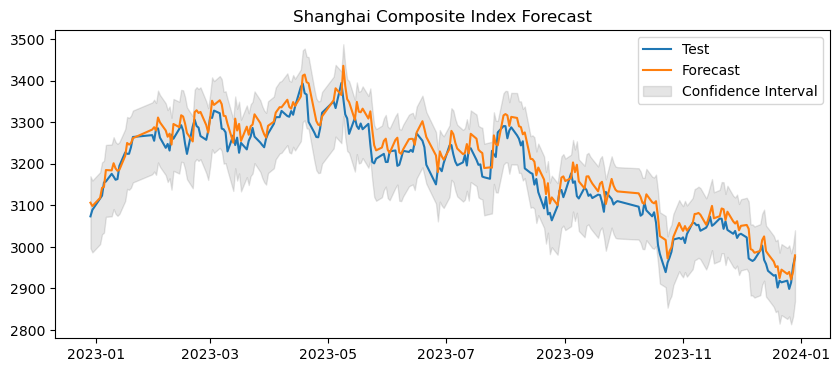

In [17]:
# Combine ARIMA and GARCH Forecasts
arima_forecast_series = pd.Series(arima_predictions, index=test.index)
conf_int_df = pd.DataFrame(confidence_intervals, index=test.index, columns=['lower', 'upper'])
fiegarch_forecast_series = pd.Series(fiegarch_predictions, index=test.index)

final_forecast = arima_forecast_series + np.sqrt(fiegarch_forecast_series)

# Evaluate the Forecast
mae = mean_absolute_error(test, final_forecast)
rmse = np.sqrt(mean_squared_error(test, final_forecast))
mape = np.mean(np.abs((test - final_forecast) / test)) * 100

# Print the evaluation metrics
print(f'MAE: {mae}')
print(f'RMSE: {rmse}')
print(f'MAPE: {mape}%')

# Plot the results
plt.figure(figsize=(10, 4))
plt.plot(test, label='Test')
plt.plot(final_forecast, label='Forecast')
plt.fill_between(conf_int_df.index, conf_int_df['lower'], conf_int_df['upper'], color='k', alpha=0.1, label='Confidence Interval')
plt.title('Shanghai Composite Index Forecast')
plt.legend()
plt.show()